# **Exploratory dynamical modeling of behavior-policy-epidemic interactions using Kalman filtering**

/tmp/ipykernel_18848/997540920.py:14: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mob = pd.read_csv(mobility_url)


alpha = 0.24693538705352194
tau = 7
b0 = 0.0442986394380089


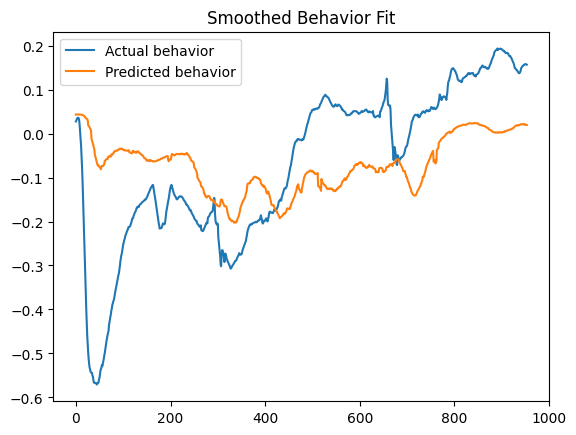

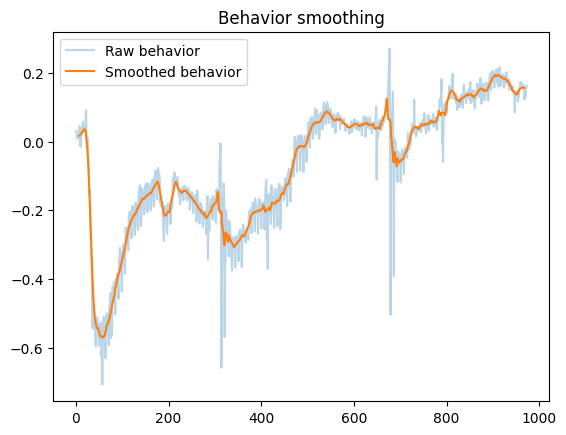

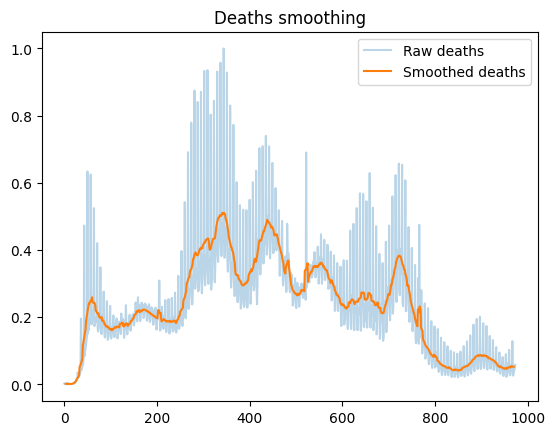

RMSE = 0.17148910163011338


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =========================
# 1. LOAD DATA
# =========================

covid_url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df_covid = pd.read_csv(covid_url)

mobility_url = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"
df_mob = pd.read_csv(mobility_url)

# =========================
# 2. PREPROCESS
# =========================

df_covid["date"] = pd.to_datetime(df_covid["date"])
df_mob["date"] = pd.to_datetime(df_mob["date"])

# Global aggregation
df_deaths = df_covid.groupby("date")["new_deaths"].sum().reset_index()
df_mob_global = df_mob.groupby("date")[
    "retail_and_recreation_percent_change_from_baseline"
].mean().reset_index()

# Merge
df = pd.merge(df_deaths, df_mob_global, on="date", how="inner").dropna()

# =========================
# 3. EXTRACT + SMOOTH
# =========================

# --- Deaths ---
D_raw = df["new_deaths"]

# 7-day smoothing (standard epidemiology)
D_smooth = D_raw.rolling(7, center=True).mean()

# --- Behavior ---
B_raw = df["retail_and_recreation_percent_change_from_baseline"]

# Slightly stronger smoothing (behavior noisier)
B_smooth = B_raw.rolling(14, center=True).mean()

# Drop NaNs from rolling
df_clean = pd.DataFrame({
    "D": D_smooth,
    "B": B_smooth
}).dropna()

# Normalize
D = df_clean["D"].values
D = D / np.max(D)

B = df_clean["B"].values / 100.0

t = np.arange(len(D))

# =========================
# 4. FIT MODEL
# =========================

def loss(params):
    alpha, tau, b0 = params
    tau = int(tau)

    if tau <= 0 or tau >= len(D):
        return 1e6

    D_shifted = D[:-tau]
    B_trim = B[tau:]

    pred = b0 - alpha * D_shifted

    return np.mean((B_trim - pred)**2)

init = [0.5, 7, 0.0]
bounds = [(0, 5), (1, 30), (-1, 1)]

res = minimize(loss, init, bounds=bounds)

alpha, tau, b0 = res.x
tau = int(tau)

print("alpha =", alpha)
print("tau =", tau)
print("b0 =", b0)

# =========================
# 5. PREDICTION
# =========================

D_shifted = D[:-tau]
B_trim = B[tau:]
B_pred = b0 - alpha * D_shifted

# =========================
# 6. PLOTS
# =========================

# Fit plot
plt.figure()
plt.plot(B_trim, label="Actual behavior")
plt.plot(B_pred, label="Predicted behavior")
plt.legend()
plt.title("Smoothed Behavior Fit")
plt.show()

# Raw vs smoothed (important diagnostic)
plt.figure()
plt.plot(B_raw.values/100.0, alpha=0.3, label="Raw behavior")
plt.plot(B_smooth.values/100.0, label="Smoothed behavior")
plt.legend()
plt.title("Behavior smoothing")
plt.show()

plt.figure()
plt.plot(D_raw.values/np.max(D_raw), alpha=0.3, label="Raw deaths")
plt.plot(D_smooth.values/np.max(D_raw), label="Smoothed deaths")
plt.legend()
plt.title("Deaths smoothing")
plt.show()

# =========================
# 7. RMSE
# =========================

rmse = np.sqrt(np.mean((B_trim - B_pred)**2))
print("RMSE =", rmse)

/tmp/ipykernel_18848/3290104979.py:15: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mob = pd.read_csv(mobility_url)


alpha = 0.24592742021228242
tau = 7
b0 = 0.04369112512022238
rho = 0.0


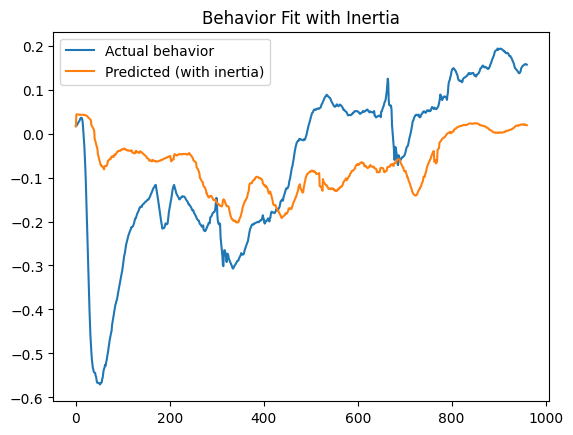

RMSE = 0.17087234155628064


In [5]:
#With Intertia
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =========================
# 1. LOAD DATA
# =========================

covid_url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df_covid = pd.read_csv(covid_url)

mobility_url = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"
df_mob = pd.read_csv(mobility_url)

# =========================
# 2. PREPROCESS
# =========================

df_covid["date"] = pd.to_datetime(df_covid["date"])
df_mob["date"] = pd.to_datetime(df_mob["date"])

df_deaths = df_covid.groupby("date")["new_deaths"].sum().reset_index()
df_mob_global = df_mob.groupby("date")[
    "retail_and_recreation_percent_change_from_baseline"
].mean().reset_index()

df = pd.merge(df_deaths, df_mob_global, on="date", how="inner").dropna()

# =========================
# 3. SMOOTH
# =========================

D_raw = df["new_deaths"]
B_raw = df["retail_and_recreation_percent_change_from_baseline"]

D_smooth = D_raw.rolling(7, center=True).mean()
B_smooth = B_raw.rolling(14, center=True).mean()

df_clean = pd.DataFrame({"D": D_smooth, "B": B_smooth}).dropna()

D = df_clean["D"].values
D = D / np.max(D)

B = df_clean["B"].values / 100.0

# =========================
# 4. MODEL WITH INERTIA
# =========================

def simulate_B(alpha, tau, b0, rho, D, B_init):
    tau = int(tau)
    B_pred = np.zeros_like(D)

    # initialize with first observed value
    B_pred[0] = B_init

    for t in range(1, len(D)):
        if t - tau >= 0:
            driver = b0 - alpha * D[t - tau]
        else:
            driver = b0

        B_pred[t] = rho * B_pred[t-1] + (1 - rho) * driver

    return B_pred

# =========================
# 5. LOSS FUNCTION
# =========================

def loss(params):
    alpha, tau, b0, rho = params

    if tau <= 0 or tau >= len(D):
        return 1e6
    if not (0 <= rho <= 1):
        return 1e6

    B_pred = simulate_B(alpha, tau, b0, rho, D, B[0])

    return np.mean((B - B_pred)**2)

# =========================
# 6. FIT
# =========================

init = [0.5, 7, 0.0, 0.8]  # alpha, tau, b0, rho
bounds = [(0, 5), (1, 30), (-1, 1), (0, 1)]

res = minimize(loss, init, bounds=bounds)

alpha, tau, b0, rho = res.x
tau = int(tau)

print("alpha =", alpha)
print("tau =", tau)
print("b0 =", b0)
print("rho =", rho)

# =========================
# 7. PREDICTION
# =========================

B_pred = simulate_B(alpha, tau, b0, rho, D, B[0])

# =========================
# 8. PLOTS
# =========================

plt.figure()
plt.plot(B, label="Actual behavior")
plt.plot(B_pred, label="Predicted (with inertia)")
plt.legend()
plt.title("Behavior Fit with Inertia")
plt.show()

# =========================
# 9. RMSE
# =========================

rmse = np.sqrt(np.mean((B - B_pred)**2))
print("RMSE =", rmse)

/tmp/ipykernel_18848/1574434367.py:16: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mob = pd.read_csv(mobility_url)


Fitted parameters:
alpha = 0.0
tau = 7
b0 = 0.40301876615059434
rho = 0.0
eta = 1.0055462279670517


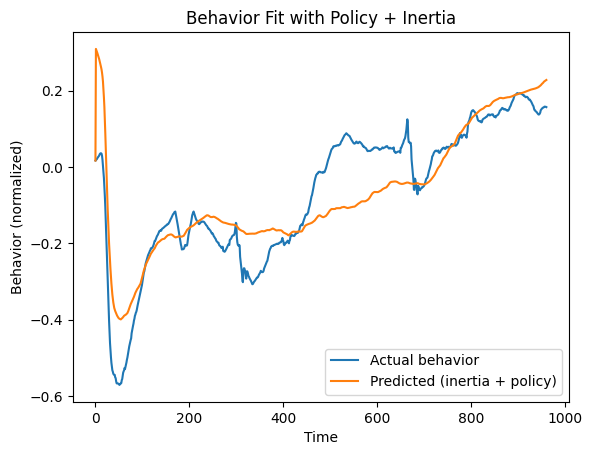

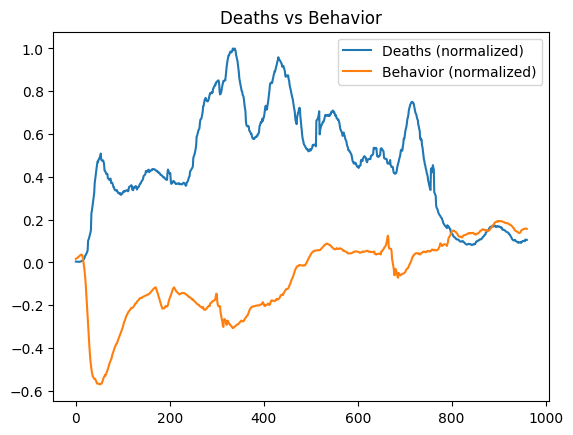

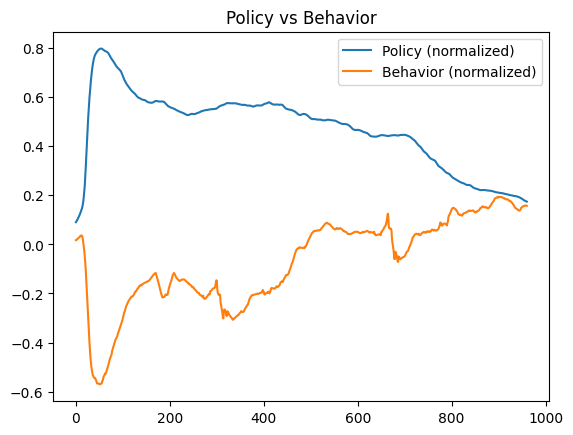

RMSE = 0.09127256105380785


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =========================
# 1. LOAD DATA
# =========================

# COVID deaths (OWID new catalog)
covid_url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df_covid = pd.read_csv(covid_url)

# Mobility (Google via OWID repo)
mobility_url = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"
df_mob = pd.read_csv(mobility_url)

# Policy (stringency index)
policy_url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df_policy = pd.read_csv(policy_url)

# =========================
# 2. PREPROCESS
# =========================

# Convert dates
df_covid["date"] = pd.to_datetime(df_covid["date"])
df_mob["date"] = pd.to_datetime(df_mob["date"])
df_policy["date"] = pd.to_datetime(df_policy["date"])

# Global aggregation
df_deaths = df_covid.groupby("date")["new_deaths"].sum().reset_index()

df_mob_global = df_mob.groupby("date")[
    "retail_and_recreation_percent_change_from_baseline"
].mean().reset_index()

df_policy_global = df_policy.groupby("date")[
    "stringency_index"
].mean().reset_index()

# Merge all datasets
df = pd.merge(df_deaths, df_mob_global, on="date", how="inner")
df = pd.merge(df, df_policy_global, on="date", how="inner")
df = df.dropna()

# =========================
# 3. SMOOTH DATA
# =========================

D_raw = df["new_deaths"]
B_raw = df["retail_and_recreation_percent_change_from_baseline"]
P_raw = df["stringency_index"]

# Rolling averages
D_smooth = D_raw.rolling(7, center=True).mean()
B_smooth = B_raw.rolling(14, center=True).mean()
P_smooth = P_raw.rolling(7, center=True).mean()

# Combine and drop NaNs
df_clean = pd.DataFrame({
    "D": D_smooth,
    "B": B_smooth,
    "P": P_smooth
}).dropna()

# =========================
# 4. NORMALIZE
# =========================

D = df_clean["D"].values
D = D / np.max(D)

B = df_clean["B"].values / 100.0
P = df_clean["P"].values / 100.0

# =========================
# 5. MODEL (INERTIA + POLICY)
# =========================

def simulate_B(alpha, tau, b0, rho, eta, D, P, B_init):
    tau = int(tau)
    B_pred = np.zeros_like(D)

    B_pred[0] = B_init

    for t in range(1, len(D)):
        if t - tau >= 0:
            driver = b0 - alpha * D[t - tau] - eta * P[t]
        else:
            driver = b0 - eta * P[t]

        B_pred[t] = rho * B_pred[t-1] + (1 - rho) * driver

    return B_pred

# =========================
# 6. LOSS FUNCTION
# =========================

def loss(params):
    alpha, tau, b0, rho, eta = params

    if tau <= 0 or tau >= len(D):
        return 1e6
    if not (0 <= rho <= 1):
        return 1e6

    B_pred = simulate_B(alpha, tau, b0, rho, eta, D, P, B[0])

    return np.mean((B - B_pred)**2)

# =========================
# 7. FIT PARAMETERS
# =========================

init = [0.5, 7, 0.0, 0.8, 0.5]
bounds = [
    (0, 5),     # alpha
    (1, 30),    # tau
    (-1, 1),    # b0
    (0, 1),     # rho
    (0, 5)      # eta
]

res = minimize(loss, init, bounds=bounds)

alpha, tau, b0, rho, eta = res.x
tau = int(tau)

print("Fitted parameters:")
print("alpha =", alpha)
print("tau =", tau)
print("b0 =", b0)
print("rho =", rho)
print("eta =", eta)

# =========================
# 8. PREDICTION
# =========================

B_pred = simulate_B(alpha, tau, b0, rho, eta, D, P, B[0])

# =========================
# 9. PLOTS
# =========================

# Behavior fit
plt.figure()
plt.plot(B, label="Actual behavior")
plt.plot(B_pred, label="Predicted (inertia + policy)")
plt.legend()
plt.title("Behavior Fit with Policy + Inertia")
plt.xlabel("Time")
plt.ylabel("Behavior (normalized)")
plt.show()

# Deaths vs behavior
plt.figure()
plt.plot(D, label="Deaths (normalized)")
plt.plot(B, label="Behavior (normalized)")
plt.legend()
plt.title("Deaths vs Behavior")
plt.show()

# Policy vs behavior
plt.figure()
plt.plot(P, label="Policy (normalized)")
plt.plot(B, label="Behavior (normalized)")
plt.legend()
plt.title("Policy vs Behavior")
plt.show()

# =========================
# 10. RMSE
# =========================

rmse = np.sqrt(np.mean((B - B_pred)**2))
print("RMSE =", rmse)

/tmp/ipykernel_18848/903805541.py:14: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mob = pd.read_csv(mobility_url)


alpha = 0.0
tau = 7
b0 = 0.4030726021295893
rho = 0.0
eta = 1.0056331771937976
delta = 0.0


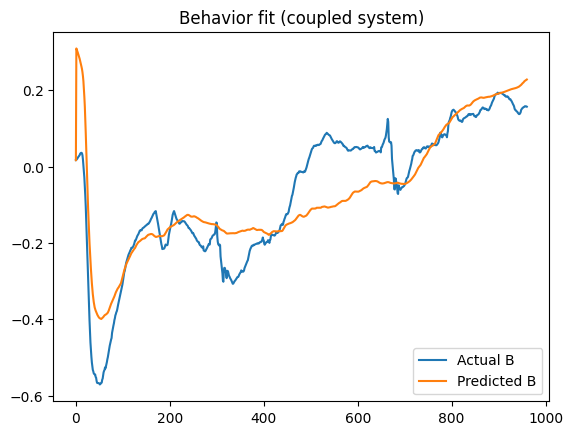

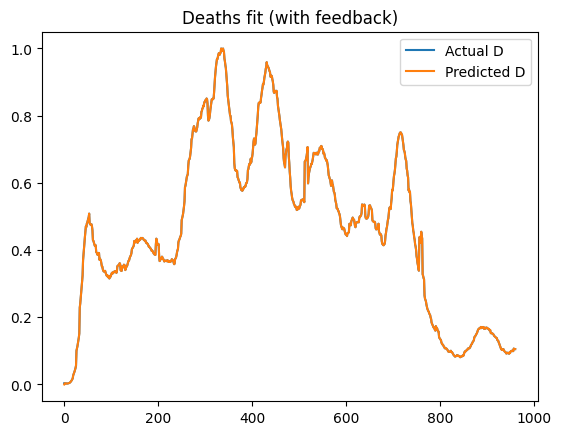

RMSE Behavior = 0.0912725632282432
RMSE Deaths = 0.00012189434974345773


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =========================
# 1. LOAD DATA
# =========================

covid_url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df_covid = pd.read_csv(covid_url)

mobility_url = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"
df_mob = pd.read_csv(mobility_url)

policy_url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df_policy = pd.read_csv(policy_url)

# =========================
# 2. PREPROCESS
# =========================

df_covid["date"] = pd.to_datetime(df_covid["date"])
df_mob["date"] = pd.to_datetime(df_mob["date"])
df_policy["date"] = pd.to_datetime(df_policy["date"])

df_deaths = df_covid.groupby("date")["new_deaths"].sum().reset_index()

df_mob_global = df_mob.groupby("date")[
    "retail_and_recreation_percent_change_from_baseline"
].mean().reset_index()

df_policy_global = df_policy.groupby("date")[
    "stringency_index"
].mean().reset_index()

df = pd.merge(df_deaths, df_mob_global, on="date", how="inner")
df = pd.merge(df, df_policy_global, on="date", how="inner")
df = df.dropna()

# =========================
# 3. SMOOTH
# =========================

D_raw = df["new_deaths"]
B_raw = df["retail_and_recreation_percent_change_from_baseline"]
P_raw = df["stringency_index"]

D_smooth = D_raw.rolling(7, center=True).mean()
B_smooth = B_raw.rolling(14, center=True).mean()
P_smooth = P_raw.rolling(7, center=True).mean()

df_clean = pd.DataFrame({
    "D": D_smooth,
    "B": B_smooth,
    "P": P_smooth
}).dropna()

# Normalize
D_data = df_clean["D"].values
D_data = D_data / np.max(D_data)

B_data = df_clean["B"].values / 100.0
P = df_clean["P"].values / 100.0

T = len(D_data)

# =========================
# 4. BASELINE EPIDEMIC W(t)
# =========================

# Use smoothed deaths as proxy baseline
# (this is key: we treat real deaths as "uncontrolled" shape)
W = D_data.copy()

# =========================
# 5. SIMULATION
# =========================

def simulate_system(params, W, P, B_init):
    alpha, tau, b0, rho, eta, delta = params
    tau = int(tau)

    B = np.zeros_like(W)
    D = np.zeros_like(W)

    B[0] = B_init

    for t in range(1, len(W)):

        # --- Behavior ---
        if t - tau >= 0:
            driver = b0 - alpha * D[t - tau] - eta * P[t]
        else:
            driver = b0 - eta * P[t]

        B[t] = rho * B[t-1] + (1 - rho) * driver

        # --- Deaths (feedback) ---
        suppression = (1 - delta * B[t])

        # keep stable
        suppression = np.clip(suppression, 0, 2)

        D[t] = W[t] * suppression

    return B, D

# =========================
# 6. LOSS FUNCTION
# =========================

def loss(params):
    alpha, tau, b0, rho, eta, delta = params

    if tau <= 0 or tau >= len(W):
        return 1e6
    if not (0 <= rho <= 1):
        return 1e6
    if not (0 <= delta <= 5):
        return 1e6

    B_pred, D_pred = simulate_system(params, W, P, B_data[0])

    # Fit BOTH behavior and deaths
    err_B = np.mean((B_data - B_pred)**2)
    err_D = np.mean((D_data - D_pred)**2)

    return err_B + err_D

# =========================
# 7. FIT
# =========================

init = [0.5, 7, 0.0, 0.8, 0.5, 0.5]

bounds = [
    (0, 5),   # alpha
    (1, 30),  # tau
    (-1, 1),  # b0
    (0, 1),   # rho
    (0, 5),   # eta
    (0, 5)    # delta
]

res = minimize(loss, init, bounds=bounds)

params = res.x
alpha, tau, b0, rho, eta, delta = params
tau = int(tau)

print("alpha =", alpha)
print("tau =", tau)
print("b0 =", b0)
print("rho =", rho)
print("eta =", eta)
print("delta =", delta)

# =========================
# 8. SIMULATE FINAL
# =========================

B_pred, D_pred = simulate_system(params, W, P, B_data[0])

# =========================
# 9. PLOTS
# =========================

plt.figure()
plt.plot(B_data, label="Actual B")
plt.plot(B_pred, label="Predicted B")
plt.legend()
plt.title("Behavior fit (coupled system)")
plt.show()

plt.figure()
plt.plot(D_data, label="Actual D")
plt.plot(D_pred, label="Predicted D")
plt.legend()
plt.title("Deaths fit (with feedback)")
plt.show()

# =========================
# 10. RMSE
# =========================

rmse_B = np.sqrt(np.mean((B_data - B_pred)**2))
rmse_D = np.sqrt(np.mean((D_data - D_pred)**2))

print("RMSE Behavior =", rmse_B)
print("RMSE Deaths =", rmse_D)

Kalman Filtering

In [9]:
import numpy as np

# =========================
# PARAMETERS (use fitted ones)
# =========================

alpha = 0.5
tau = 7
b0 = 0.0
rho = 0.8
eta = 0.5
delta = 0.5

# Noise levels (tune these!)
Q = np.diag([0.001, 0.001])   # process noise
R = np.diag([0.01, 0.01])     # observation noise

# =========================
# STATE TRANSITION FUNCTION
# =========================

def f(x, t, B_hist, D_hist):
    B_prev, D_prev = x

    # delayed D
    if t - tau >= 0:
        D_lag = D_hist[t - tau]
    else:
        D_lag = D_prev

    # Behavior update
    B = rho * B_prev + (1 - rho) * (b0 - alpha * D_lag - eta * P[t])

    # Death update
    D = W[t] * (1 - delta * B)
    D = np.clip(D, 0, 2)

    return np.array([B, D])

# =========================
# JACOBIAN (approximate)
# =========================

def jacobian(x, t):
    eps = 1e-5
    J = np.zeros((2,2))

    for i in range(2):
        dx = np.zeros(2)
        dx[i] = eps

        f1 = f(x + dx, t, B_est, D_est)
        f2 = f(x - dx, t, B_est, D_est)

        J[:, i] = (f1 - f2) / (2 * eps)

    return J

# =========================
# EKF
# =========================

T = len(B_data)

x_est = np.zeros((T, 2))  # [B, D]
P_est = np.eye(2)

# initialize
x_est[0] = [B_data[0], D_data[0]]

B_est = x_est[:,0]
D_est = x_est[:,1]

for t in range(1, T):

    # ---- Predict ----
    x_pred = f(x_est[t-1], t, B_est, D_est)
    F = jacobian(x_est[t-1], t)

    P_pred = F @ P_est @ F.T + Q

    # ---- Update ----
    y = np.array([B_data[t], D_data[t]])

    H = np.eye(2)  # direct observation

    y_pred = x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_est[t] = x_pred + K @ (y - y_pred)
    P_est = (np.eye(2) - K @ H) @ P_pred

    B_est[t] = x_est[t,0]
    D_est[t] = x_est[t,1]

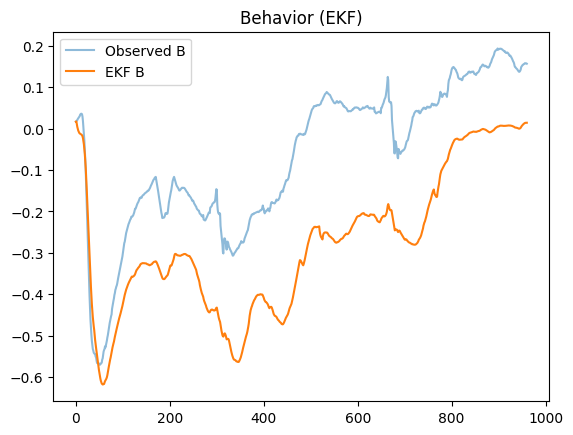

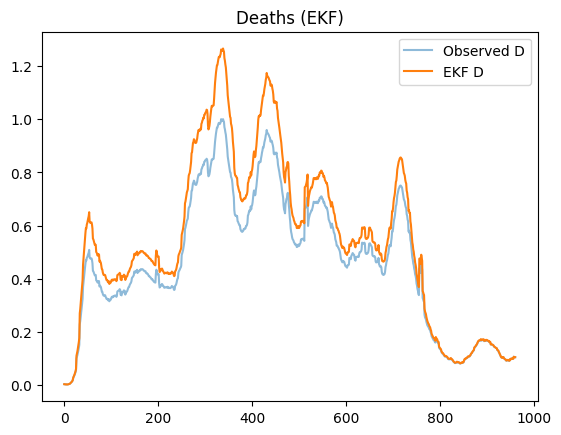

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(B_data, label="Observed B", alpha=0.5)
plt.plot(B_est, label="EKF B")
plt.legend()
plt.title("Behavior (EKF)")
plt.show()

plt.figure()
plt.plot(D_data, label="Observed D", alpha=0.5)
plt.plot(D_est, label="EKF D")
plt.legend()
plt.title("Deaths (EKF)")
plt.show()

Unscented Kalman Filter

In [11]:
import numpy as np

# =========================
# PARAMETERS (use fitted)
# =========================

alpha = 0.5
tau = 7
b0 = 0.0
rho = 0.8
eta = 0.5
delta = 0.5

# UKF parameters
n = 2  # state dimension
alpha_ukf = 1e-3
beta = 2
kappa = 0

lambda_ = alpha_ukf**2 * (n + kappa) - n

# Noise
Q = np.diag([0.001, 0.001])
R = np.diag([0.01, 0.01])

# =========================
# SIGMA POINTS
# =========================

def sigma_points(x, P):
    sigma_pts = [x]
    sqrtP = np.linalg.cholesky((n + lambda_) * P)

    for i in range(n):
        sigma_pts.append(x + sqrtP[:, i])
        sigma_pts.append(x - sqrtP[:, i])

    return np.array(sigma_pts)

# Weights
Wm = np.full(2*n+1, 1/(2*(n+lambda_)))
Wc = np.full(2*n+1, 1/(2*(n+lambda_)))
Wm[0] = lambda_ / (n + lambda_)
Wc[0] = Wm[0] + (1 - alpha_ukf**2 + beta)

# =========================
# DYNAMICS
# =========================

def f(x, t, B_hist, D_hist):
    B_prev, D_prev = x

    if t - tau >= 0:
        D_lag = D_hist[t - tau]
    else:
        D_lag = D_prev

    # Behavior
    B = rho * B_prev + (1 - rho) * (b0 - alpha * D_lag - eta * P[t])

    # Deaths
    D = W[t] * (1 - delta * B)
    D = np.clip(D, 0, 2)

    return np.array([B, D])

def h(x):
    return x  # direct observation

# =========================
# UKF LOOP
# =========================

T = len(B_data)

x_est = np.zeros((T, 2))
P_est = np.eye(2)

# init
x_est[0] = [B_data[0], D_data[0]]

B_est = x_est[:,0]
D_est = x_est[:,1]

for t in range(1, T):

    # ---- Sigma points ----
    X = sigma_points(x_est[t-1], P_est)

    # ---- Predict ----
    X_pred = np.array([f(x, t, B_est, D_est) for x in X])

    x_pred = np.sum(Wm[:, None] * X_pred, axis=0)

    P_pred = Q.copy()
    for i in range(len(X_pred)):
        diff = (X_pred[i] - x_pred).reshape(-1,1)
        P_pred += Wc[i] * (diff @ diff.T)

    # ---- Measurement ----
    Y = np.array([h(x) for x in X_pred])
    y_pred = np.sum(Wm[:, None] * Y, axis=0)

    S = R.copy()
    for i in range(len(Y)):
        diff = (Y[i] - y_pred).reshape(-1,1)
        S += Wc[i] * (diff @ diff.T)

    # Cross covariance
    C = np.zeros((2,2))
    for i in range(len(X_pred)):
        dx = (X_pred[i] - x_pred).reshape(-1,1)
        dy = (Y[i] - y_pred).reshape(-1,1)
        C += Wc[i] * (dx @ dy.T)

    # Kalman gain
    K = C @ np.linalg.inv(S)

    # Observation
    y = np.array([B_data[t], D_data[t]])

    # Update
    x_est[t] = x_pred + K @ (y - y_pred)
    P_est = P_pred - K @ S @ K.T

    B_est[t] = x_est[t,0]
    D_est[t] = x_est[t,1]

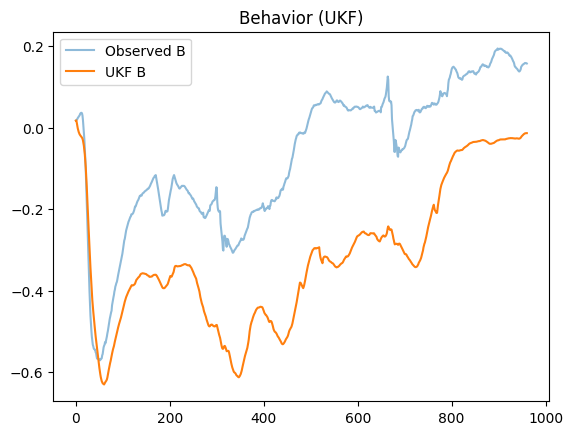

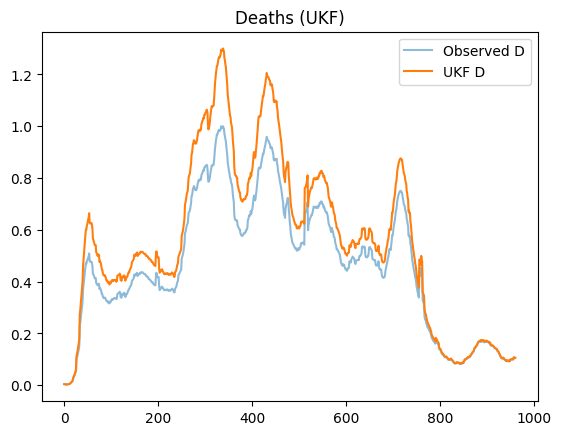

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(B_data, label="Observed B", alpha=0.5)
plt.plot(B_est, label="UKF B")
plt.legend()
plt.title("Behavior (UKF)")
plt.show()

plt.figure()
plt.plot(D_data, label="Observed D", alpha=0.5)
plt.plot(D_est, label="UKF D")
plt.legend()
plt.title("Deaths (UKF)")
plt.show()

Parameter estimation within UKF

In [13]:
import numpy as np

# =========================
# STATE DIMENSION
# =========================

n = 6  # [B, D, alpha, rho, eta, delta]

alpha_ukf = 1e-3
beta = 2
kappa = 0

lambda_ = alpha_ukf**2 * (n + kappa) - n

# Weights
Wm = np.full(2*n+1, 1/(2*(n+lambda_)))
Wc = np.full(2*n+1, 1/(2*(n+lambda_)))
Wm[0] = lambda_ / (n + lambda_)
Wc[0] = Wm[0] + (1 - alpha_ukf**2 + beta)

# =========================
# NOISE MATRICES
# =========================

Q = np.diag([
    0.001,  # B
    0.001,  # D
    1e-5,   # alpha
    1e-5,   # rho
    1e-5,   # eta
    1e-5    # delta
])

R = np.diag([0.01, 0.01])

# =========================
# SIGMA POINTS
# =========================

def sigma_points(x, P):
    sigma_pts = [x]
    sqrtP = np.linalg.cholesky((n + lambda_) * P)

    for i in range(n):
        sigma_pts.append(x + sqrtP[:, i])
        sigma_pts.append(x - sqrtP[:, i])

    return np.array(sigma_pts)

# =========================
# DYNAMICS
# =========================

def f(x, t, B_hist, D_hist):
    B_prev, D_prev, alpha, rho, eta, delta = x

    # constrain parameters
    rho = np.clip(rho, 0, 1)
    delta = np.clip(delta, 0, 5)
    alpha = np.clip(alpha, 0, 5)
    eta = np.clip(eta, 0, 5)

    # delayed deaths
    if t - tau >= 0:
        D_lag = D_hist[t - tau]
    else:
        D_lag = D_prev

    # Behavior
    B = rho * B_prev + (1 - rho) * (b0 - alpha * D_lag - eta * P[t])

    # Deaths
    D = W[t] * (1 - delta * B)
    D = np.clip(D, 0, 2)

    # Parameters evolve slowly (identity)
    return np.array([B, D, alpha, rho, eta, delta])

# =========================
# OBSERVATION
# =========================

def h(x):
    return x[:2]  # observe B and D only

# =========================
# UKF LOOP
# =========================

T = len(B_data)

x_est = np.zeros((T, n))
P_est = np.eye(n)

# Initial guess
x_est[0] = [
    B_data[0],
    D_data[0],
    0.5,  # alpha
    0.8,  # rho
    0.5,  # eta
    0.5   # delta
]

B_est = x_est[:,0]
D_est = x_est[:,1]

param_est = x_est[:,2:]

for t in range(1, T):

    # ---- Sigma points ----
    X = sigma_points(x_est[t-1], P_est)

    # ---- Predict ----
    X_pred = np.array([f(x, t, B_est, D_est) for x in X])

    x_pred = np.sum(Wm[:, None] * X_pred, axis=0)

    P_pred = Q.copy()
    for i in range(len(X_pred)):
        diff = (X_pred[i] - x_pred).reshape(-1,1)
        P_pred += Wc[i] * (diff @ diff.T)

    # ---- Measurement ----
    Y = np.array([h(x) for x in X_pred])
    y_pred = np.sum(Wm[:, None] * Y, axis=0)

    S = R.copy()
    for i in range(len(Y)):
        diff = (Y[i] - y_pred).reshape(-1,1)
        S += Wc[i] * (diff @ diff.T)

    # Cross covariance
    C = np.zeros((n, 2))
    for i in range(len(X_pred)):
        dx = (X_pred[i] - x_pred).reshape(-1,1)
        dy = (Y[i] - y_pred).reshape(-1,1)
        C += Wc[i] * (dx @ dy.T)

    K = C @ np.linalg.inv(S)

    y = np.array([B_data[t], D_data[t]])

    x_est[t] = x_pred + K @ (y - y_pred)
    P_est = P_pred - K @ S @ K.T

    B_est[t] = x_est[t,0]
    D_est[t] = x_est[t,1]

# =========================
# RESULTS
# =========================

alpha_est = x_est[:,2]
rho_est   = x_est[:,3]
eta_est   = x_est[:,4]
delta_est = x_est[:,5]

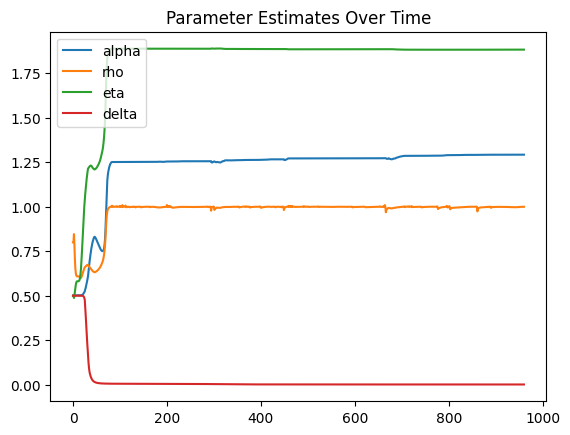

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(alpha_est, label="alpha")
plt.plot(rho_est, label="rho")
plt.plot(eta_est, label="eta")
plt.plot(delta_est, label="delta")
plt.legend()
plt.title("Parameter Estimates Over Time")
plt.show()

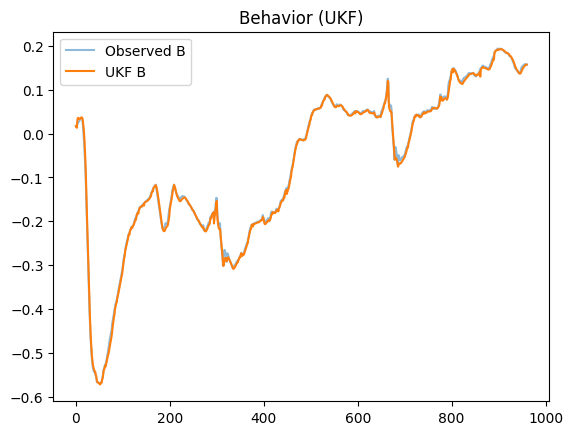

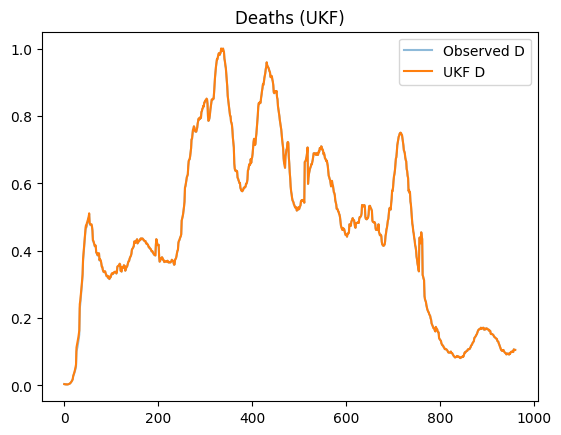

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(B_data, label="Observed B", alpha=0.5)
plt.plot(B_est, label="UKF B")
plt.legend()
plt.title("Behavior (UKF)")
plt.show()

plt.figure()
plt.plot(D_data, label="Observed D", alpha=0.5)
plt.plot(D_est, label="UKF D")
plt.legend()
plt.title("Deaths (UKF)")
plt.show()